# Técnicas avanzadas de diseño de software
## Heurísticas de Diseño Orientado a Objetos

----

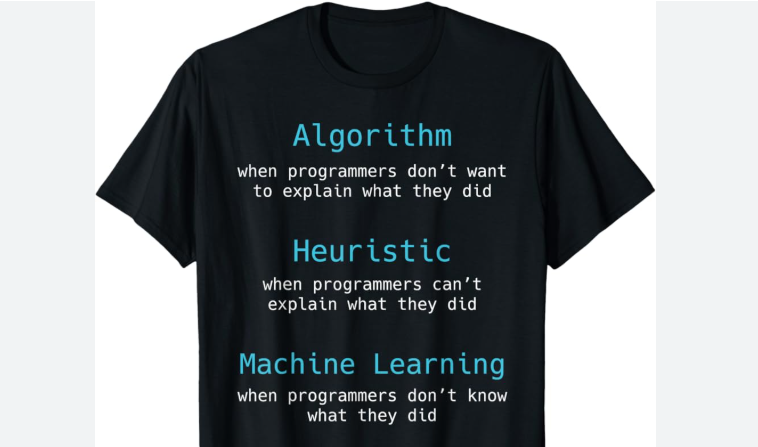

# Heurísticas de Diseño Orientado a Objetos

- Son principios que guían la construcción de sistemas de software más mantenibles, robustos y expresivos.
- Actúan como "reglas prácticas" que ayudan a los desarrolladores a tomar mejores decisiones de diseño:
- No son reglas rígidas sino guías que nos acercan a un diseño más cercano al modelo mental humano,
- Facilita la evolución del software a lo largo del tiempo y mejora la comunicación entre equipos técnicos y de negocio.

# 1. Inmutabilidad

- Los objetos inmutables no pueden cambiar después de creados
- Beneficios:
  - Seguridad en entornos multithread
  - Reducción de efectos secundarios
  - Mayor previsibilidad del código

# 2. Inmutabilidad - Ejemplo en Python

In [1]:
class Coordenada:
    def __init__(self, x, y):
        self._x = x
        self._y = y
    
    @property
    def x(self):
        return self._x
    
    @property
    def y(self):
        return self._y
    
    def desplazar(self, dx, dy):
        # En lugar de modificar, devolvemos un nuevo objeto
        return Coordenada(self._x + dx, self._y + dy)

# Uso
punto = Coordenada(5, 10)
nuevo_punto = punto.desplazar(3, 4)  # No modifica punto original
print(f"Original: ({punto.x}, {punto.y})")  # Original: (5, 10)
print(f"Nuevo: ({nuevo_punto.x}, {nuevo_punto.y})")  # Nuevo: (8, 14)


Original: (5, 10)
Nuevo: (8, 14)


# 3. Lenguaje Ubicuo y Metáforas del Dominio

- Usa el lenguaje de expertos del dominio en tu código
- Beneficios:
  - Mejora la comunicación entre equipos técnicos y de negocio
  - Facilita la comprensión del sistema
  - Reduce traducciones entre dominio y solución técnica

# 4. Lenguaje Ubicuo - Ejemplo en Python

In [ ]:
# Enfoque sin lenguaje ubicuo
class UserData:
    def __init__(self, name, balance):
        self.name = name
        self.balance = balance
    
    def modify_balance(self, amount):
        self.balance += amount

# Enfoque con lenguaje ubicuo - dominio bancario
class Cliente:
    def __init__(self, nombre, saldo):
        self.nombre = nombre
        self.saldo = saldo
    
    def depositar(self, monto):
        self.saldo += monto
    
    def retirar(self, monto):
        if monto <= self.saldo:
            self.saldo -= monto
            return True
        return False


# 5. Valores Nulos (Null Object Pattern)

- Evita usar `None` o `null` directamente (`NULL` es el nulo del lenguaje, **NO** de tu dominio)
- Crea un objeto "nulo" con comportamiento neutro
- $NULL \neq \text{Valor por defecto}$
- Beneficios:
  - Evita verificaciones constantes de nulidad
  - Reduce excepciones de tipo NullPointerException
  - Código más limpio y legible

# 6. Valores Nulos - Ejemplo en Python

In [ ]:
class Usuario:
    def __init__(self, nombre, email):
        self.nombre = nombre
        self.email = email
    
    def enviar_notificacion(self, mensaje):
        print(f"Enviando a {self.email}: {mensaje}")

# Objeto Nulo
class UsuarioAnonimo:
    def __init__(self):
        self.nombre = "Invitado"
        self.email = "no-email"
    
    def enviar_notificacion(self, mensaje):
        # No hace nada, comportamiento neutro
        pass

# Uso
def obtener_usuario(id):
    # Si no encuentra usuario, retorna UsuarioAnonimo en vez de None
    if id in base_de_datos:
        return base_de_datos[id]
    return UsuarioAnonimo()

# Con este patrón podemos usar el objeto sin verificar si es None
usuario = obtener_usuario(123)
usuario.enviar_notificacion("Hola")  # Funciona sin importar el tipo de usuario


# 7. Arquitectura del Sistema en el Código

- El código debe revelar la estructura del sistema
- Organiza en capas/paquetes que reflejen la arquitectura
- Beneficios:
  - Mayor comprensión de la estructura global
  - Mejor navegabilidad del código
  - Separación clara de responsabilidades

# 8. Arquitectura del Sistema - Ejemplo en Python

```bash
mi_aplicacion/
├── dominio/          # Lógica de dominio y reglas de negocio
│   ├── __init__.py
│   ├── cliente.py
│   ├── cuenta.py
│   └── transaccion.py
├── infraestructura/  # Implementación de persistencia, servicios externos
│   ├── __init__.py
│   ├── repositorios/
│   └── servicios_externos/
├── aplicacion/       # Casos de uso, coordinación
│   ├── __init__.py
│   ├── servicios/
│   └── dto/
└── interfaces/       # Interfaces de usuario (API, CLI, etc.)
    ├── __init__.py
    ├── api/
    └── cli/
```


# 9. Entidades del Dominio como Objetos

- Modela conceptos clave del negocio como objetos
- Incorpora comportamiento, no solo datos
- Beneficios:
  - Modelo rico que encapsula reglas de negocio
  - Código más expresivo y cercano al dominio
  - Mejor encapsulamiento de lógica crítica

# 10. Entidades del Dominio - Ejemplo en Python

In [ ]:
# Antipatrón: Modelo anémico (solo datos)
class CuentaAnemica:
    def __init__(self, id, saldo, tipo):
        self.id = id
        self.saldo = saldo
        self.tipo = tipo

# En algún servicio externo:
def realizar_retiro(cuenta, monto):
    if cuenta.tipo == "ahorro" and monto > 1000:
        return False
    if cuenta.saldo < monto:
        return False
    cuenta.saldo -= monto
    return True

# Mejor enfoque: Modelo rico con comportamiento
class Cuenta:
    def __init__(self, id, saldo, limite_retiro=None):
        self.id = id
        self._saldo = saldo
        self._limite_retiro = limite_retiro
    
    def retirar(self, monto):
        if self._limite_retiro and monto > self._limite_retiro:
            raise ValueError(f"Excede límite de retiro de {self._limite_retiro}")
        if monto > self._saldo:
            raise ValueError("Fondos insuficientes")
        self._saldo -= monto
        return monto
    
    def depositar(self, monto):
        if monto <= 0:
            raise ValueError("El monto debe ser positivo")
        self._saldo += monto

# Especialización de entidades
class CuentaAhorro(Cuenta):
    def __init__(self, id, saldo):
        super().__init__(id, saldo, limite_retiro=1000)


# 11. Invarianza de Objetos

- Define condiciones que siempre deben cumplirse en un objeto
- Verifica estas condiciones en constructores y métodos
- Explotar lo más temprano posible frente a invarianzas.
- Beneficios:
  - Garantiza integridad de los datos
  - Previene estados inconsistentes
  - Facilita el razonamiento sobre el comportamiento

# 12. Invarianza de Objetos - Ejemplo en Python

In [ ]:
class Rectangulo:
    def __init__(self, ancho, alto):
        # Invariante: dimensiones siempre positivas
        if ancho <= 0 or alto <= 0:
            raise ValueError("Las dimensiones deben ser positivas")
        self._ancho = ancho
        self._alto = alto
    
    @property
    def ancho(self):
        return self._ancho
    
    @ancho.setter
    def ancho(self, valor):
        # Mantiene la invariante en modificaciones
        if valor <= 0:
            raise ValueError("El ancho debe ser positivo")
        self._ancho = valor
    
    @property
    def alto(self):
        return self._alto
    
    @alto.setter
    def alto(self, valor):
        # Mantiene la invariante en modificaciones
        if valor <= 0:
            raise ValueError("El alto debe ser positivo")
        self._alto = valor
    
    @property
    def area(self):
        # La invariante garantiza que el área siempre será positiva
        return self._ancho * self._alto


# 13. Encapsulamiento

- Oculta los detalles internos de implementación
- Expone solo interfaces bien definidas
- Beneficios:
  - Permite cambiar implementaciones sin afectar al cliente
  - Reduce acoplamiento
  - Mejora el mantenimiento y testabilidad

# 14. Encapsulamiento - Ejemplo en Python

In [ ]:
class GestorDeArchivos:
    def __init__(self, directorio_base):
        self._directorio_base = directorio_base
        self._archivos_abiertos = {}
    
    def leer_archivo(self, nombre_archivo):
        """Interfaz pública para leer un archivo"""
        ruta = self._construir_ruta(nombre_archivo)
        contenido = self._leer_contenido(ruta)
        return self._procesar_contenido(contenido)
    
    def escribir_archivo(self, nombre_archivo, contenido):
        """Interfaz pública para escribir un archivo"""
        ruta = self._construir_ruta(nombre_archivo)
        contenido_procesado = self._preparar_contenido(contenido)
        self._escribir_contenido(ruta, contenido_procesado)
    
    # Métodos privados - detalles de implementación
    def _construir_ruta(self, nombre_archivo):
        import os
        return os.path.join(self._directorio_base, nombre_archivo)
    
    def _leer_contenido(self, ruta):
        with open(ruta, 'r') as f:
            return f.read()
    
    def _escribir_contenido(self, ruta, contenido):
        with open(ruta, 'w') as f:
            f.write(contenido)
    
    def _procesar_contenido(self, contenido):
        # Implementación interna que podría cambiar
        return contenido.strip()
    
    def _preparar_contenido(self, contenido):
        # Implementación interna que podría cambiar
        return contenido + '\n'


# 15. Objetos Cohesivos y Completos

- Cada objeto debe tener una responsabilidad única (cohesión)
- Debe contener todos los comportamientos relacionados (completitud)
- Se puede usar el patron builder o contextos para solucionar problemas complejos.
- Beneficios:
  - Código más mantenible y comprensible
  - Mejor reutilización
  - Reduce el acoplamiento entre clases

# 16. Objetos Cohesivos - Ejemplo en Python

In [ ]:
# Clase con baja cohesión - múltiples responsabilidades
class UsuarioMultiProposito:
    def __init__(self, nombre, email):
        self.nombre = nombre
        self.email = email
        self.carrito = []
    
    def autenticar(self, password):
        # Lógica de autenticación
        pass
    
    def agregar_al_carrito(self, producto):
        self.carrito.append(producto)
    
    def calcular_total(self):
        return sum(p.precio for p in self.carrito)
    
    def enviar_email(self, asunto, mensaje):
        # Lógica de envío de email
        pass

# Mejor enfoque: Alta cohesión
class Usuario:
    def __init__(self, nombre, email):
        self.nombre = nombre
        self.email = email
    
    def autenticar(self, password):
        # Lógica de autenticación
        pass

class Carrito:
    def __init__(self, usuario):
        self.usuario = usuario
        self.items = []
    
    def agregar(self, producto, cantidad=1):
        self.items.append({"producto": producto, "cantidad": cantidad})
    
    def calcular_total(self):
        return sum(item["producto"].precio * item["cantidad"] for item in self.items)

class NotificacionEmail:
    def __init__(self, servicio_email):
        self.servicio_email = servicio_email
    
    def enviar(self, destino, asunto, mensaje):
        # Lógica de envío usando servicio_email
        pass


# Claves para Aplicar estas Heurísticas

- **Empieza con el dominio**: Entiende el problema antes de codificar
- **Evoluciona el diseño**: Refactoriza constantemente
- **Prioriza la legibilidad**: El código debe comunicar intenciones
- **Testea por comportamiento**: Verifica que los objetos cumplen su propósito
- **Busca equilibrio**: No sobrediseñes ni compliques innecesariamente

# Beneficios de Seguir las Heurísticas de DOO

- **Mantenibilidad**: Código más fácil de mantener y evolucionar
- **Comprensibilidad**: Diseño más cercano al modelo mental humano
- **Robustez**: Menos errores y comportamiento más predecible
- **Testabilidad**: Objetos bien definidos son más fáciles de probar
- **Adaptabilidad**: Facilita el cambio mediante encapsulamiento
- **Comunicación**: Mejora el entendimiento entre equipo técnico y de negocio

**Recuerda**: Las heurísticas son guías, no reglas rígidas. Adapta según el contexto y necesidades específicas de tu proyecto.